In [26]:
import pandas as pd
from matplotlib.pyplot import title,grid,figure,plot,xlabel,ylabel,savefig
from numpy import zeros,asarray
from numpy import diff
from statsmodels.tsa.stattools import adfuller

In [27]:
#pip install statsmodels

# Importar archivo de datos "life-expectancy.csv"

Limpieza de la base de datos

In [2]:
#Importar los datos de la esperanza de vida de los países del mundo
df = pd.read_csv("life-expectancy.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19526 entries, 0 to 19525
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Entity           19526 non-null  str    
 1   Code             19526 non-null  str    
 2   Year             19526 non-null  int64  
 3   Life expectancy  19526 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 610.3 KB


In [3]:
df.shape

(19526, 4)

In [4]:
#Países que se encuentran registrados en la columna "Entity"
df["Entity"].unique()

<StringArray>
[        'Afghanistan',             'Albania',             'Algeria',
      'American Samoa',             'Andorra',              'Angola',
            'Anguilla', 'Antigua and Barbuda',           'Argentina',
             'Armenia',
 ...
          'Uzbekistan',             'Vanuatu',             'Vatican',
           'Venezuela',             'Vietnam',   'Wallis and Futuna',
      'Western Sahara',               'Yemen',              'Zambia',
            'Zimbabwe']
Length: 237, dtype: str

In [5]:
#Eliminaremos la columna "Code"
df.drop(["Code"], axis=1, inplace=True) # axis 1 columna, axis 0 fila
#Renombrar algunas columnas
df = df.rename(columns={'Entity': 'Pais', 'Year': 'Año', 'Life expectancy': "Esperanza de vida"})
df.head(10)

,Pais,Año,Esperanza de vida
0,Afghanistan,1950,28.1563
1,Afghanistan,1951,28.5836
2,Afghanistan,1952,29.0138
3,Afghanistan,1953,29.4521
4,Afghanistan,1954,29.6975
5,Afghanistan,1955,30.3660
6,Afghanistan,1956,30.8303
7,Afghanistan,1957,31.3451
8,Afghanistan,1958,31.8400
9,Afghanistan,1959,32.3365


# Generaremos un nuevo dataframe sólo con los registros de México

In [6]:
df_mex = df[df["Pais"]=="Mexico"]
df_mex.head(10)

,Pais,Año,Esperanza de vida
11060,Mexico,1893,23.29
11061,Mexico,1894,26.62
11062,Mexico,1895,29.52
11063,Mexico,1896,28.80
11064,Mexico,1897,26.24
11065,Mexico,1898,27.03
11066,Mexico,1899,24.98
11067,Mexico,1900,25.00
11068,Mexico,1901,26.65
11069,Mexico,1902,28.37


<Figure size 800x600 with 0 Axes>

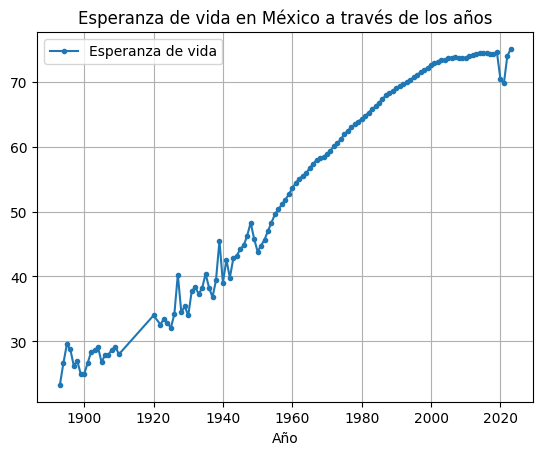

In [7]:
figure(figsize=(8,6))
df_mex.plot(x='Año', y='Esperanza de vida', kind='line', marker='o', markersize=3)
title("Esperanza de vida en México a través de los años")
grid()

In [8]:
#Exportar datos de México
df_mex.info()
df_mex.drop(["Pais"], axis=1, inplace=True)
df_mex.to_csv("Esperanza_vida_Mexico.csv")

<class 'pandas.DataFrame'>
RangeIndex: 121 entries, 11060 to 11180
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Pais               121 non-null    str    
 1   Año                121 non-null    int64  
 2   Esperanza de vida  121 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


## Cálculo de media y autocovarianza de una serie de tiempo

Sea $x=\{x_1,x_2,...,x_n\}$ un conjunto de $n$ observaciones de una serie de tiempo. Su media se define como $\bar{x}=\frac{1}{n}\sum_{i=1}^nx_i$, mientras que su varianza se define como $S^2=\frac{\sum_{i=1}^n(x_i-\bar{x})^2}{n-1}$.

In [9]:
serie = pd.Series(df_mex["Esperanza de vida"])

#Calcular el promedio
promedio = serie.mean()

#Calcular la varianza
varianza = serie.var(ddof=1)

print(f"Promedio: {promedio}")
print(f"Varianza: {varianza}")

Promedio: 53.09291157024794
Varianza: 286.7650618926984


# Suavizar serie de tiempo

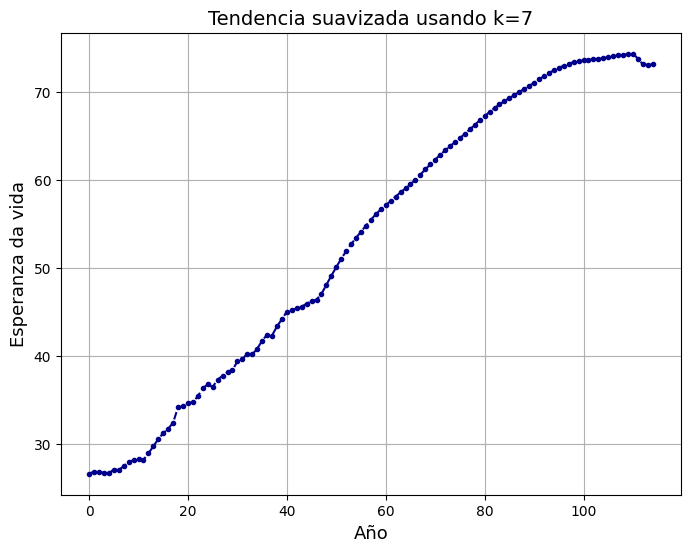

In [10]:
#Realizar medias móviles centradas de k días
def media_movil(x_fil,k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = sum(x[i-step:i+step+1])/k
    out = asarray(suav)
    return out

#Tamaño de la ventana de tiempo
k = 7
serie_suav = media_movil(serie, k)
new_lenght = len(serie)-k+1

figure(figsize = (8,6))
plot(serie_suav, linestyle = "--", marker = "o", markersize=3, color="darkblue")
grid()
xlabel("Año", fontsize=13)
ylabel("Esperanza da vida", fontsize=13)
title("Tendencia suavizada usando k="+str(k), fontsize=14)
savefig("Serie_suavizada.png", dpi=350)

In [11]:
#Calcular el promedio
promedio = serie_suav.mean()

#Calcular la varianza
varianza = serie_suav.var(ddof=1)

print(f"Promedio: {promedio}")
print(f"Varianza: {varianza}")

Promedio: 53.26568708074534
Varianza: 270.1931637123737


# armenia

In [12]:
df_arm = df[df["Pais"]=="Armenia"]

<Figure size 1000x800 with 0 Axes>

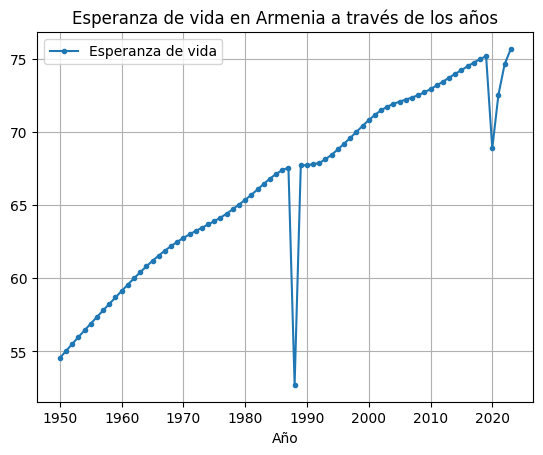

In [13]:
figure(figsize=(10,8))
df_arm.plot(x='Año', y='Esperanza de vida', kind='line', marker='o', markersize=3)
title("Esperanza de vida en Armenia a través de los años")
grid()

# Media ($\mu$) y varianza ($\sigma$)

In [14]:
serie = pd.Series(df_arm["Esperanza de vida"])

#Calcular el promedio
promedio = serie.mean()

#Calcular la varianza
varianza = serie.var(ddof=1)

print(f"Promedio: {promedio}")
print(f"Varianza: {varianza}")

Promedio: 66.30816756756758
Varianza: 37.12155979235839


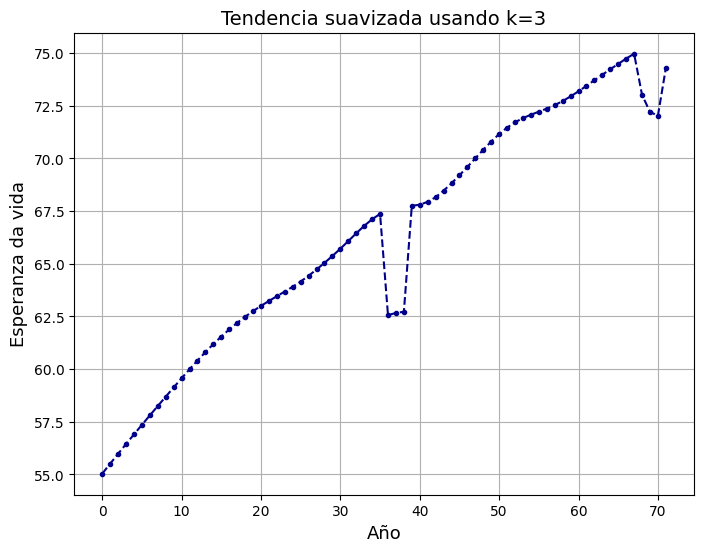

In [18]:
#Realizar medias móviles centradas de k días
def media_movil(x_fil,k=7):
    x = x_fil.tolist()
    n = len(x)-(k-1)
    suav = zeros((n))
    step = int((k-1)/2)
    for i in range(step,n+step):
        suav[i-step] = sum(x[i-step:i+step+1])/k
    out = asarray(suav)
    return out

#Tamaño de la ventana de tiempo
k = 3
serie_suav = media_movil(serie, k)
new_lenght = len(serie)-k+1

figure(figsize = (8,6))
plot(serie_suav, linestyle = "--", marker = "o", markersize=3, color="darkblue")
grid()
xlabel("Año", fontsize=13)
ylabel("Esperanza da vida", fontsize=13)
title("Tendencia suavizada usando k="+str(k), fontsize=14)
savefig("Serie_suavizada.png", dpi=350)

# Diff

In [29]:
serie_diff = diff(serie_suav)


Text(0.5, 1.0, 'Serie diferenciada 3')

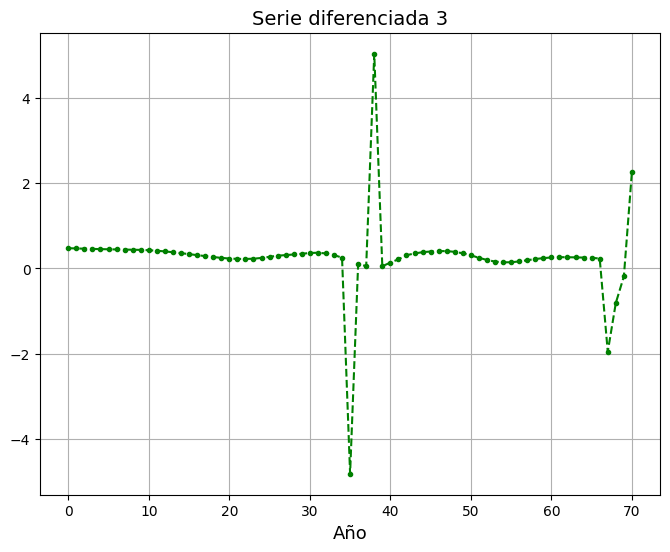

In [30]:
figure(figsize = (8,6))
plot(serie_diff, linestyle = "--", marker = "o", markersize=3, color="green")
grid()
xlabel("Año", fontsize=13)
title("Serie diferenciada "+str(k), fontsize=14)

In [33]:
dftest_act = adfuller(serie_diff, autolag='AIC')
result_act = pd.Series(dftest_act[0:4], index=['Test Statistic','P-value','Lags Used','No of Observations'])
for key,value in dftest_act[4].items():
    result_act['Critical Value (%s)'%key] = value
print("Prueba estadística para la serie de tiempo diferenciada")
print(result_act)

Prueba estadística para la serie de tiempo diferenciada
Test Statistic         -7.956629e+00
P-value                 3.025118e-12
Lags Used               2.000000e+00
No of Observations      6.800000e+01
Critical Value (1%)    -3.530399e+00
Critical Value (5%)    -2.905087e+00
Critical Value (10%)   -2.590001e+00
dtype: float64
